In [ ]:
# 1) KÜTÜPHANELER
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving THYAO_2023_2025.xlsx to THYAO_2023_2025.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("THYAO_2023_2025.xlsx")
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,THYAO.IS,THYAO.IS,THYAO.IS,THYAO.IS,THYAO.IS
1,Date,NaN,NaN,NaN,NaN,NaN
2,2023-01-02 00:00:00,143.406601,143.699669,138.815248,139.108302,60745183
3,2023-01-03 00:00:00,143.992737,146.92339,143.015853,144.871942,73564352
4,2023-01-04 00:00:00,141.159775,144.774244,140.280585,144.481175,50055440


In [ ]:
df = df.iloc[2:].copy()

df.rename(columns={"Price": "Date"}, inplace=True)

df["Date"] = pd.to_datetime(df["Date"])

numeric_cols = ["Close", "High", "Low", "Open", "Volume"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

df = df.sort_values("Date")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749 entries, 2 to 750
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    749 non-null    datetime64[ns]
 1   Close   749 non-null    float64       
 2   High    749 non-null    float64       
 3   Low     749 non-null    float64       
 4   Open    749 non-null    float64       
 5   Volume  749 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 35.2 KB


In [ ]:
# Lag değişkenleri
df["Close_lag_1"] = df["Close"].shift(1)
df["Close_lag_3"] = df["Close"].shift(3)
df["Close_lag_5"] = df["Close"].shift(5)
df["Close_lag_10"] = df["Close"].shift(10)

# Hareketli ortalamalar
df["MA_5"] = df["Close"].rolling(window=5).mean()
df["MA_10"] = df["Close"].rolling(window=10).mean()
df["MA_20"] = df["Close"].rolling(window=20).mean()

# Günlük getiri
df["Return"] = df["Close"].pct_change()

# Eksik değerleri temizle
df = df.dropna().reset_index(drop=True)

df.head()

,Date,Close,High,Low,Open,Volume,Close_lag_1,Close_lag_3,Close_lag_5,Close_lag_10,MA_5,MA_10,MA_20,Return
0,2023-01-27,146.337250,147.118760,140.573624,146.337250,81105028,146.727997,146.239563,149.365585,131.586304,147.060147,146.640085,141.135344,-0.002663
1,2023-01-30,141.452835,146.825698,141.452835,146.532630,48666913,146.337250,148.291031,147.704895,141.062073,145.809735,146.679161,141.037655,-0.033378
2,2023-01-31,134.419281,141.159776,134.419281,141.159776,65737449,141.452835,146.727997,146.239563,143.992737,143.445679,145.721815,140.558982,-0.049724
3,2023-02-01,127.776459,137.056859,127.776459,135.884601,64560389,134.419281,146.337250,148.291031,145.653427,139.342764,143.934119,139.889817,-0.049419
4,2023-02-02,131.488617,133.246997,122.208210,127.190318,103057422,127.776459,141.452835,146.727997,151.026291,136.294888,141.980351,139.538139,0.029052


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          730 non-null    datetime64[ns]
 1   Close         730 non-null    float64       
 2   High          730 non-null    float64       
 3   Low           730 non-null    float64       
 4   Open          730 non-null    float64       
 5   Volume        730 non-null    int64         
 6   Close_lag_1   730 non-null    float64       
 7   Close_lag_3   730 non-null    float64       
 8   Close_lag_5   730 non-null    float64       
 9   Close_lag_10  730 non-null    float64       
 10  MA_5          730 non-null    float64       
 11  MA_10         730 non-null    float64       
 12  MA_20         730 non-null    float64       
 13  Return        730 non-null    float64       
dtypes: datetime64[ns](1), float64(12), int64(1)
memory usage: 80.0 KB


In [ ]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Close_lag_1",
    "Close_lag_3",
    "Close_lag_5",
    "Close_lag_10",
    "MA_5",
    "MA_10",
    "MA_20",
    "Return"
]

target = "Close"

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_data.shape

(730, 13)

In [ ]:
def create_sequences(data, time_step=30):

    X = []
    y = []

    close_index = features.index("Close")

    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i])
        y.append(data[i, close_index])

    return np.array(X), np.array(y)

In [ ]:
import numpy as np
X, y = create_sequences(scaled_data, time_step=30)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (700, 30, 13)
y shape: (700,)


In [ ]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (560, 30, 13)
X_test: (140, 30, 13)
y_train: (560,)
y_test: (140,)


In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0664 - val_loss: 0.0033
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0122 - val_loss: 0.0032
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0091 - val_loss: 0.0035
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0081 - val_loss: 0.0029
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0076 - val_loss: 0.0031
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0081 - val_loss: 0.0035
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0065 - val_loss: 0.0031
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0076 - val_loss: 0.0035
Epoch 9/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0061 - val_loss: 0.0035
Epoch 10/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0067 - val_loss: 0.0026
Epoch 11/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0066 - val_loss: 0.0025
Epoch 12/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

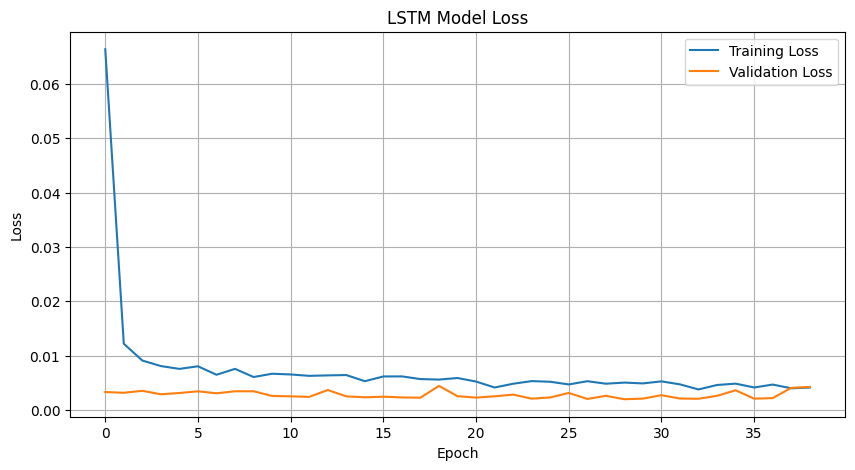

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


In [ ]:
def inverse_close(scaled_close_values):

    dummy = np.zeros((len(scaled_close_values), len(features)))

    close_index = features.index("Close")

    dummy[:, close_index] = scaled_close_values.reshape(-1)

    return scaler.inverse_transform(dummy)[:, close_index]

In [ ]:
y_test_real = inverse_close(y_test)
y_pred_real = inverse_close(y_pred)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print("RMSE =", rmse)
print("MAE =", mae)
print("R² =", r2)

RMSE = 8.987227721219302
MAE = 6.832248816993641
R² = 0.8463303917432083


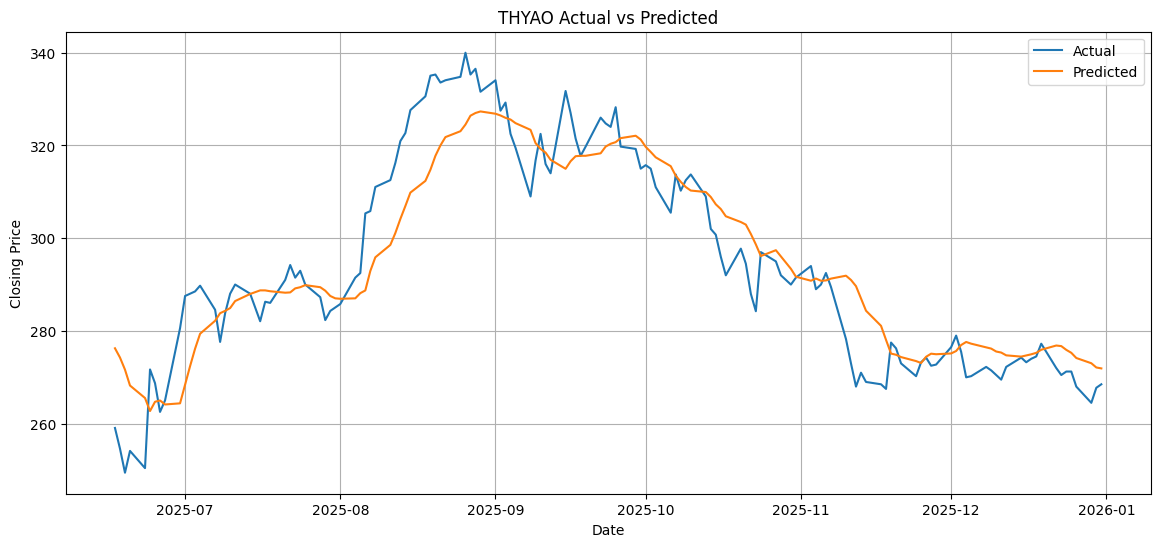

In [ ]:
test_dates = df["Date"].iloc[-len(y_test_real):]

plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    y_test_real,
    label="Actual",
)

plt.plot(
    test_dates,
    y_pred_real,
    label="Predicted",
)

plt.title("THYAO Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

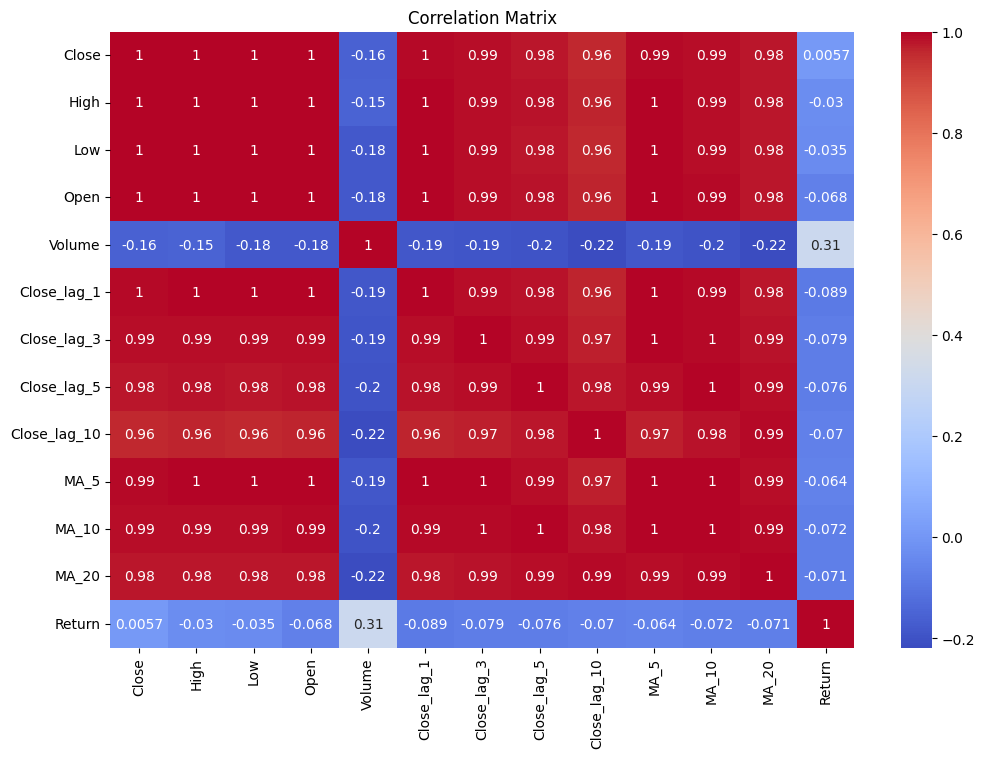

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.drop("Date", axis=1).corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

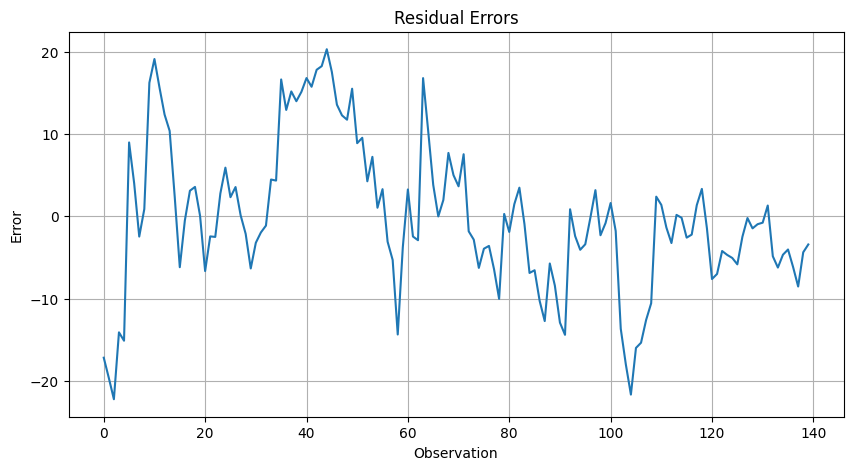

In [ ]:
residuals = y_test_real - y_pred_real

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residual Errors")
plt.xlabel("Observation")
plt.ylabel("Error")
plt.grid(True)
plt.show()

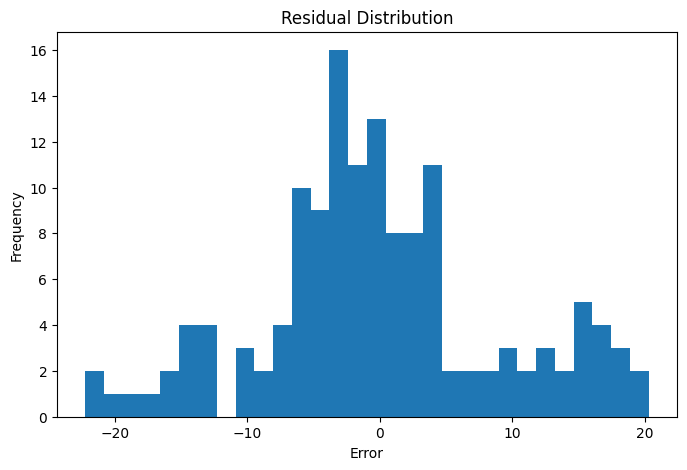

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

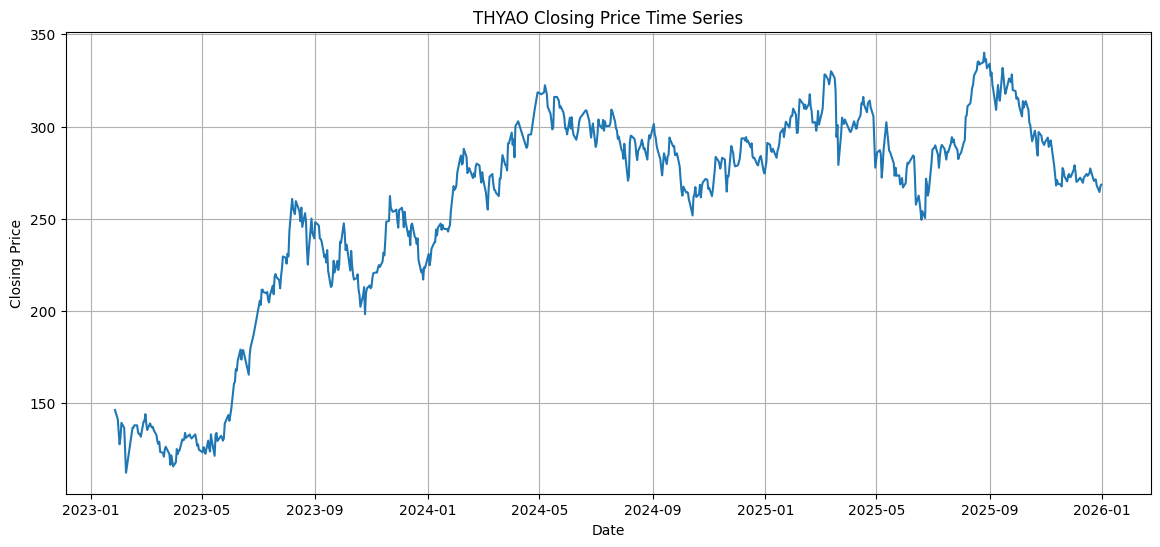

In [ ]:
# 1) Kapanış fiyatı grafiği
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Close"])
plt.title("THYAO Closing Price Time Series")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)
plt.savefig("kapanis_fiyati.png", dpi=300, bbox_inches="tight")
plt.show()

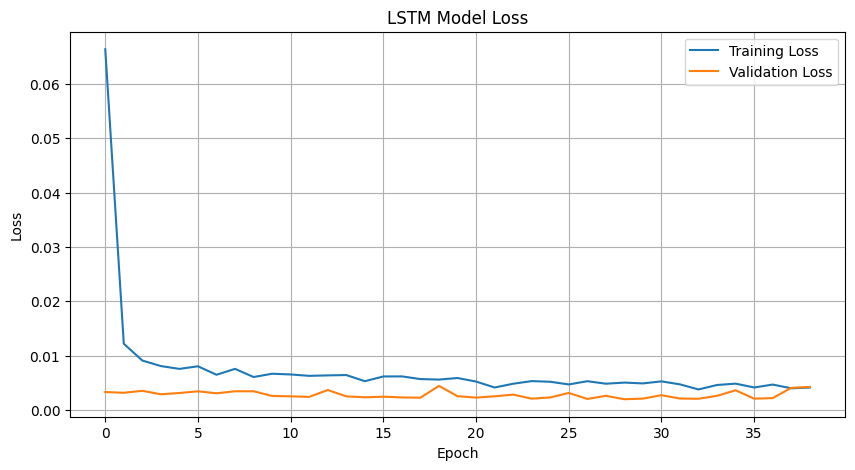

In [ ]:
# 2) Loss grafiği
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("loss_grafigi.png", dpi=300, bbox_inches="tight")
plt.show()

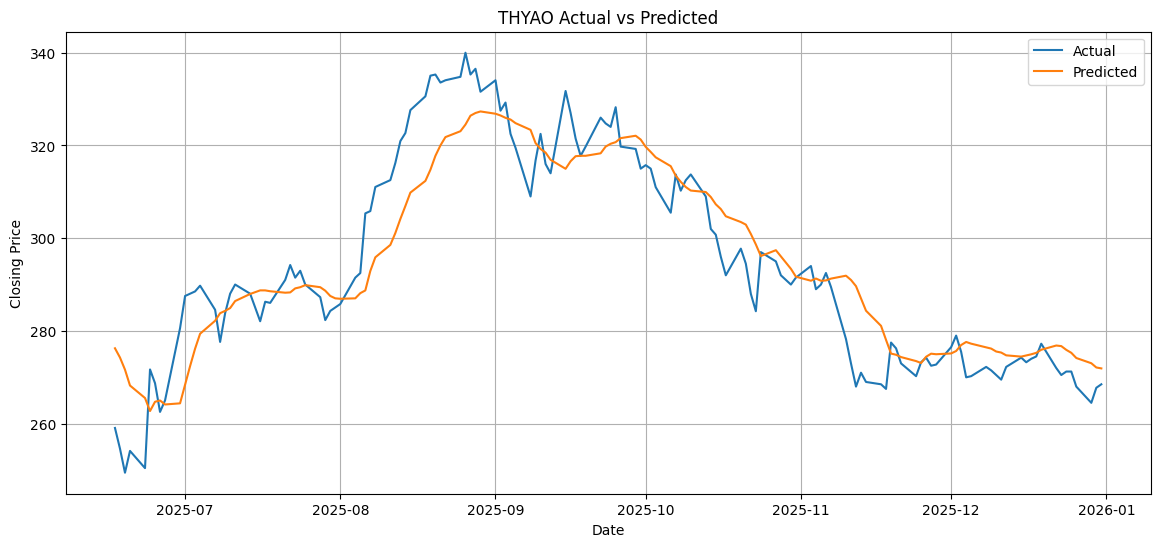

In [ ]:
# 3) Actual vs Predicted grafiği
plt.figure(figsize=(14,6))
plt.plot(test_dates, y_test_real, label="Actual")
plt.plot(test_dates, y_pred_real, label="Predicted")
plt.title("THYAO Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

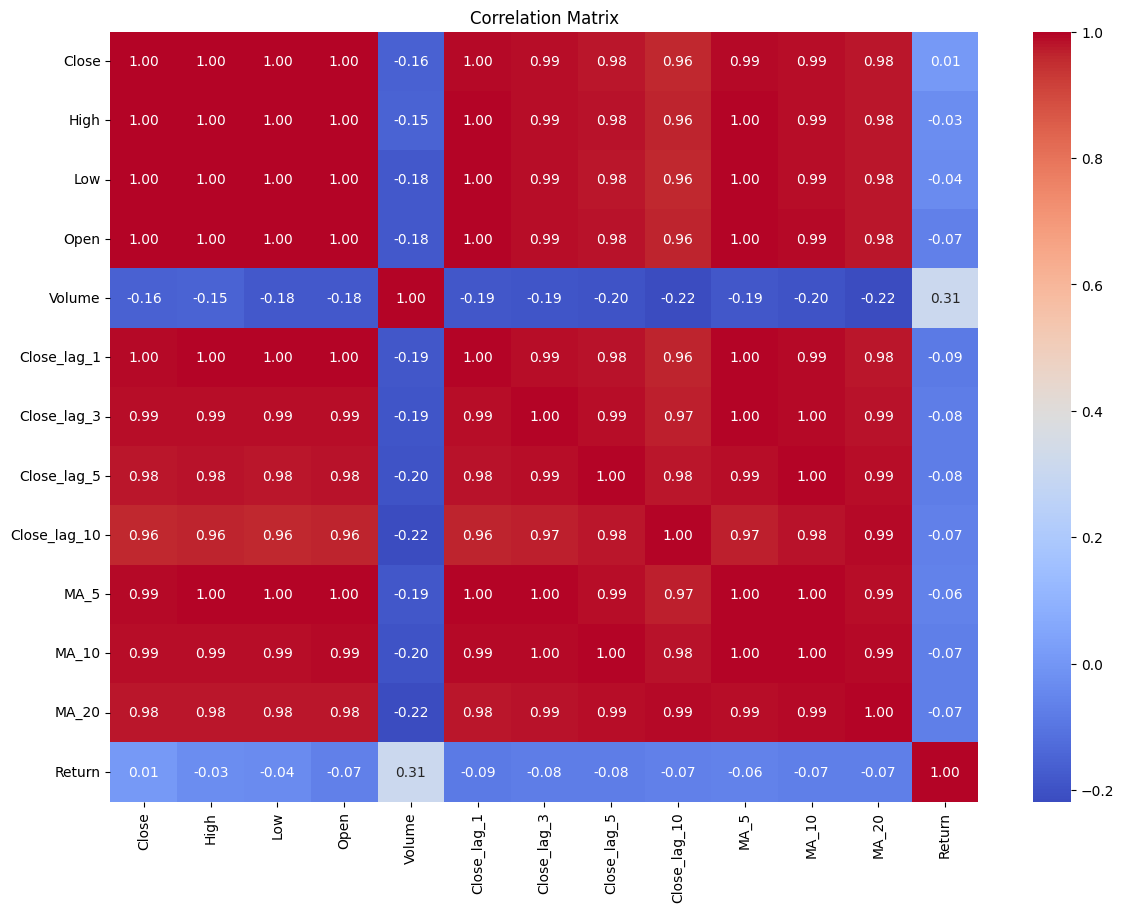

In [ ]:
# 4) Korelasyon matrisi
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(df.drop("Date", axis=1).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

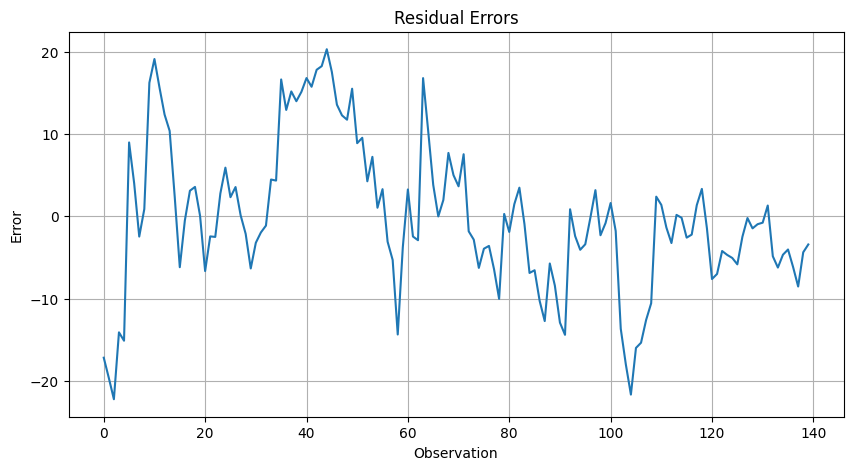

In [ ]:
# 5) Residual error grafiği
residuals = y_test_real - y_pred_real

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residual Errors")
plt.xlabel("Observation")
plt.ylabel("Error")
plt.grid(True)
plt.savefig("residual_errors.png", dpi=300, bbox_inches="tight")
plt.show()

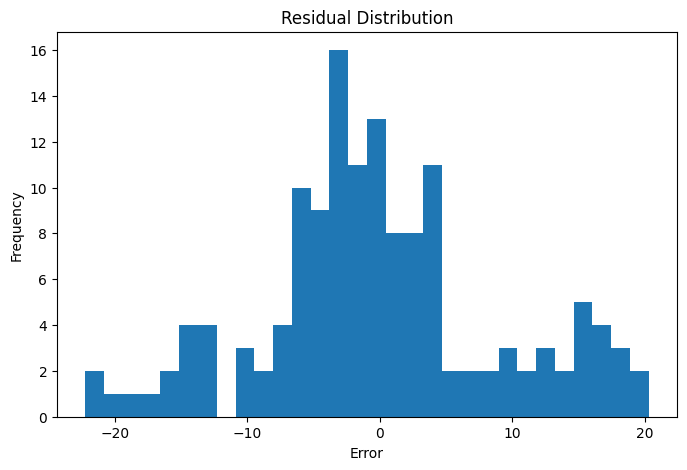

In [ ]:
# 6) Residual distribution grafiği
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.savefig("residual_distribution.png", dpi=300, bbox_inches="tight")
plt.show()